In [55]:
# model based off https://towardsdatascience.com/going-beyond-99-mnist-handwritten-digits-recognition-cfff96337392
from typing import List, Callable
from tinygrad import Tensor, TinyJit, nn, GlobalCounters, Device, dtypes
from tinygrad.helpers import getenv, colored
from tinygrad.nn.datasets import mnist
from tinygrad.nn.state import safe_save, safe_load, get_state_dict, load_state_dict, get_parameters
from tqdm import trange
import matplotlib.pyplot as plt

In [42]:
GPUS = [f'{Device.DEFAULT}:{i}' for i in range(getenv("GPUS", 2))]

In [43]:
class Model:
  def __init__(self):
    self.layers: List[Callable[[Tensor], Tensor]] = [
      nn.Conv2d(1, 32, 5), Tensor.relu,
      nn.Conv2d(32, 32, 5), Tensor.relu,
      nn.BatchNorm2d(32), Tensor.max_pool2d,
      nn.Conv2d(32, 64, 3), Tensor.relu,
      nn.Conv2d(64, 64, 3), Tensor.relu,
      nn.BatchNorm2d(64), Tensor.max_pool2d,
      lambda x: x.flatten(1), nn.Linear(576, 10)]

  def __call__(self, x:Tensor) -> Tensor: return x.sequential(self.layers)

In [44]:
class AE:
    def __init__(self):
        self.net:  List[Callable[[Tensor], Tensor]] = [
            nn.Linear(28*28, 512), Tensor.gelu, Tensor.dropout,
            nn.Linear(512, 256), Tensor.gelu, Tensor.dropout,
            nn.Linear(256, 128), Tensor.gelu, Tensor.dropout,
            nn.Linear(128, 64), Tensor.gelu, Tensor.dropout,
            nn.Linear(64, 32), Tensor.gelu,

            # Decoder
            nn.Linear(32, 64), Tensor.gelu, Tensor.dropout,
            nn.Linear(64, 128), Tensor.gelu, Tensor.dropout,
            nn.Linear(128, 256), Tensor.gelu, Tensor.dropout,
            nn.Linear(256, 512), Tensor.gelu, Tensor.dropout,
            nn.Linear(512, 784), Tensor.sigmoid,
        ]
        
    def __call__(self, x: Tensor) -> Tensor: return x.sequential(self.net)

In [45]:
def mse(model, d: Tensor) -> Tensor: return model(d).sub(d).square().mean()
def mse(model, d: Tensor) -> Tensor: return model(d).sub(d).abs().mean()

In [108]:
def save_model(epoch: int, model): safe_save(get_state_dict(model), f"best.safetensors")

def load_model(path: str, model): load_state_dict(model, safe_load(path))

In [47]:
X_train, Y_train, X_test, Y_test = mnist()
# we shard the test data on axis 0
X_test.shard_(GPUS, axis=0)
Y_test.shard_(GPUS, axis=0)

<Tensor <MLB self.axis=0 self.real=[True, True] 
CUDA ShapeTracker(views=(View(shape=(5000,), strides=(1,), offset=0, mask=None, contiguous=True),))
CUDA:1 ShapeTracker(views=(View(shape=(5000,), strides=(1,), offset=0, mask=None, contiguous=True),))> on ('CUDA', 'CUDA:1') with grad None>

In [48]:
model = AE()
for k, x in get_state_dict(model).items(): x.to_(GPUS)  # we put a copy of the model on every GPU
opt = nn.optim.Adam(get_parameters(model), lr=0.01)

In [107]:
@TinyJit
def train_step(bs: int = 64, tot: int = 60_000) -> Tensor:
    with Tensor.train():
        opt.zero_grad()
        #samples = Tensor.randint(5, high=X_train.shape[0])
        for i in range(0, tot, bs):
            samples = Tensor.arange(i*bs, (i+1) * bs)
            Xt = X_train[samples].shard_(GPUS, axis=0).reshape(-1, 1, 784)
            loss = mse(model, Xt).backward()
            opt.step()
        return loss

@TinyJit
def get_test_acc() -> Tensor: return (model(X_test.reshape(-1, 1, 784)) == X_test.reshape(-1, 1, 784)).mean()*100

def print_acc(): print(f"Accuracy: {get_test_acc().item():.2f}%")

In [50]:
test_acc = float('nan')
best_loss = float('inf')
EPS = 10
bs = 2048
losses = []

for i in (t:=trange(EPS)):
    GlobalCounters.reset()   # NOTE: this makes it nice for DEBUG=2 timing
    loss = train_step(bs=bs)
    li = loss.item()
  
    losses.append(li)
    if i%10 == 9: test_acc = get_test_acc().item()
    t.set_description(f"loss: {loss.item():6.2f} test_accuracy: {test_acc:5.2f}%")
    if li < best_loss:
        best_loss = li
        save_model(i, model)

print(f"The best loss is {best_loss:.4f}")

loss:   0.00 test_accuracy: 80.72%: 100%|██████████| 10/10 [00:46<00:00,  4.70s/it]

The best loss is 0.0000


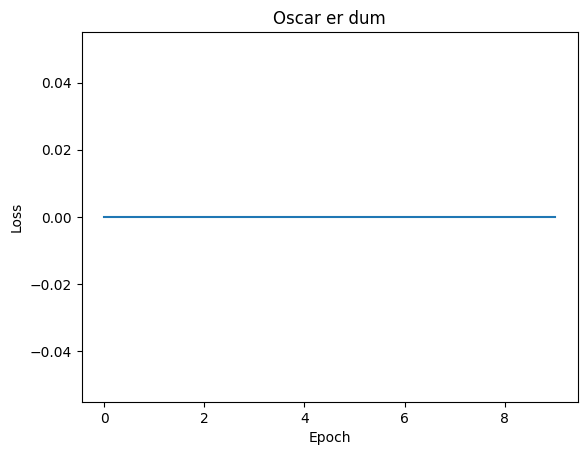

In [51]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Oscar er dum")
plt.show()

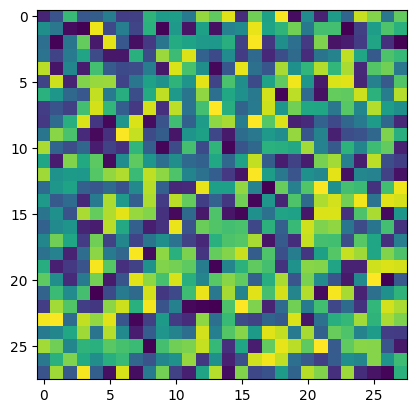

In [66]:
data = Tensor.rand(28, 28, dtype=dtypes.float32)
img = data.numpy()
plt.imshow(img)
plt.show()

In [98]:
newd = data.reshape(1, -1).shard(devices=GPUS)
res = model(newd)
newimg = res.flatten().reshape(28, 28).numpy()

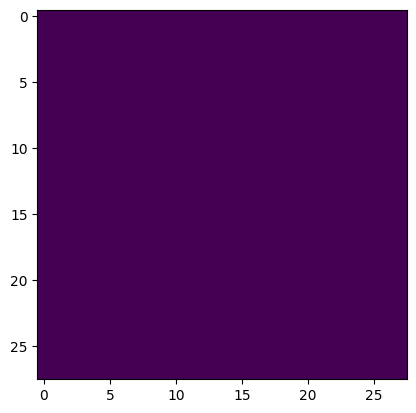

In [99]:
plt.imshow(newimg)
plt.show()